Cleaned Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 121180 entries, 48966 to 91810
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               121180 non-null  float64       
 1   Order ID            121180 non-null  object        
 2   Date                121180 non-null  datetime64[ns]
 3   Status              121180 non-null  object        
 4   Fulfilment          121180 non-null  object        
 5   Sales Channel       121180 non-null  object        
 6   ship-service-level  121180 non-null  object        
 7   Style               121180 non-null  object        
 8   SKU                 121180 non-null  object        
 9   Category            121180 non-null  object        
 10  Size                121180 non-null  object        
 11  ASIN                121180 non-null  object        
 12  Courier Status      116044 non-null  object        
 13  Qty         

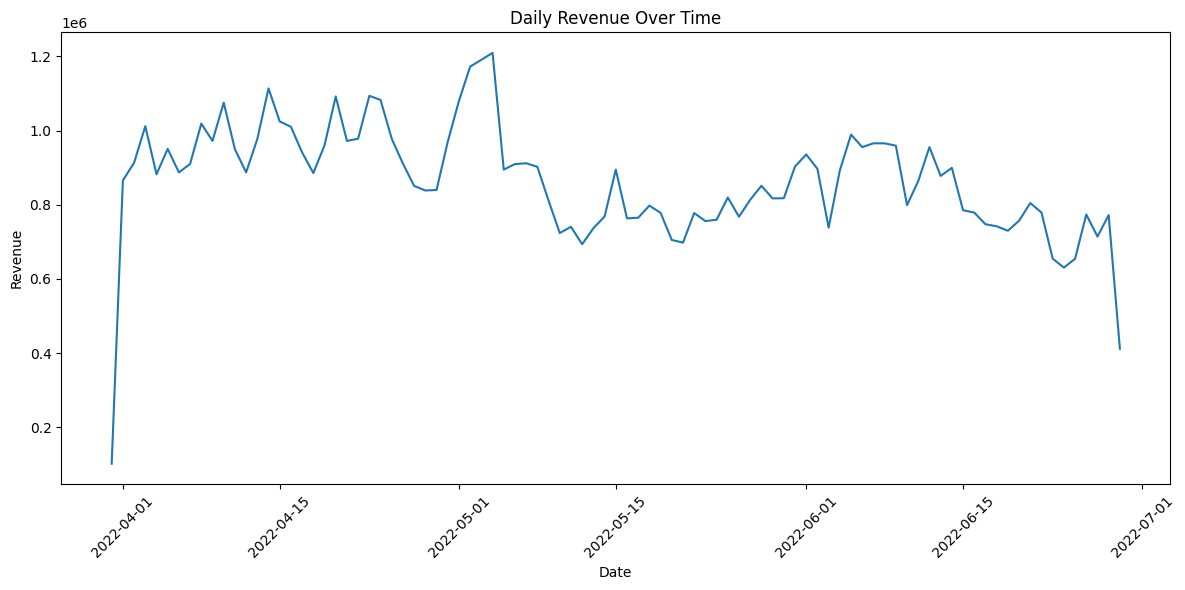

/tmp/ipython-input-4208832901.py:32: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.resample('M', on='Date')['Amount'].sum()


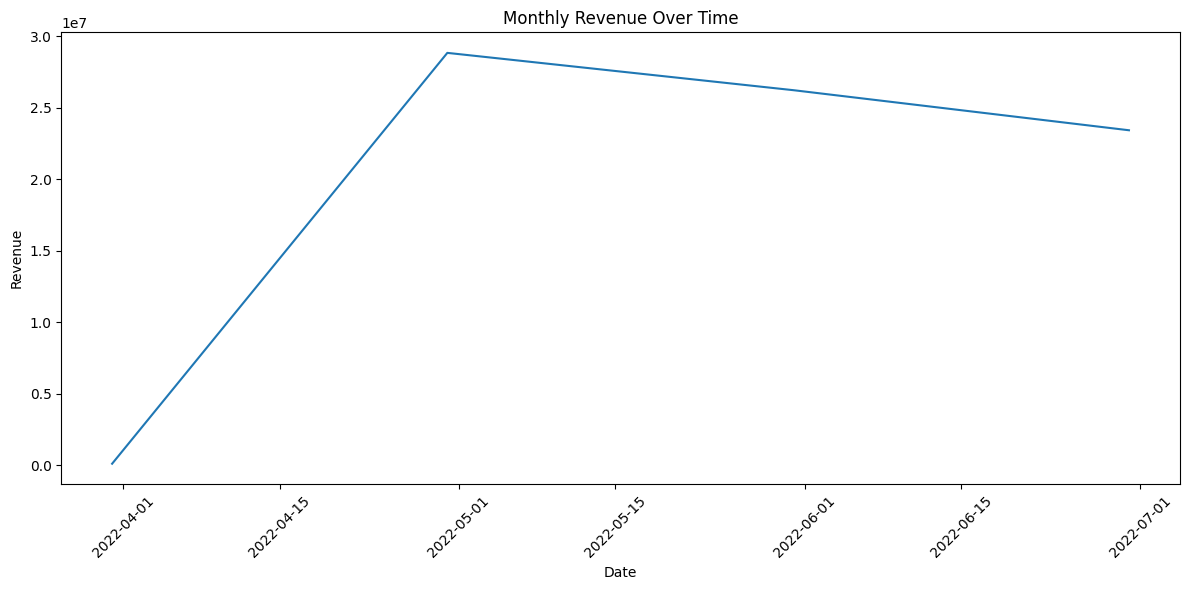

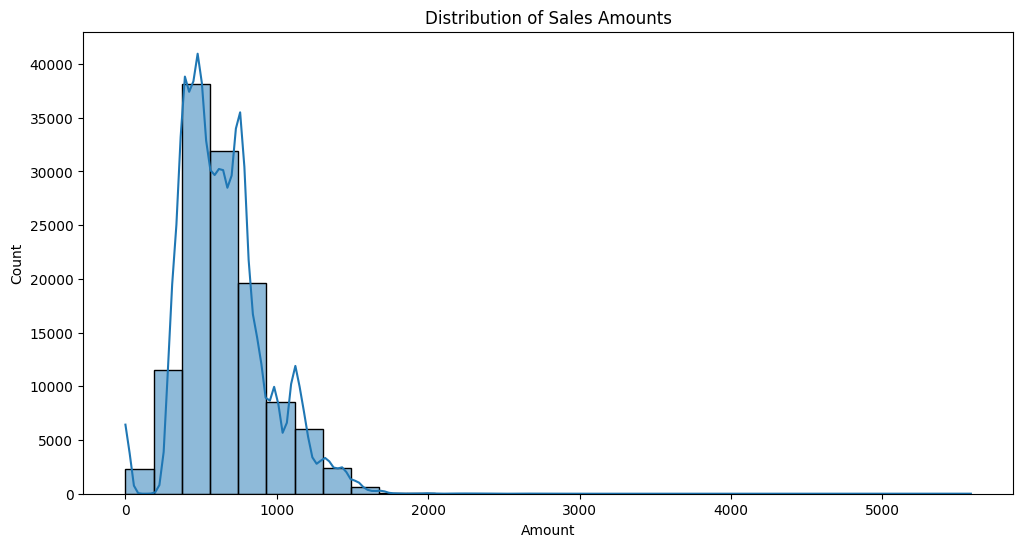

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/raw_sales.csv', low_memory=False)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df = df.dropna(subset=["Date", "Amount"])

df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

df = df.dropna(subset=["Amount"])

df = df.sort_values("Date")

print("Cleaned Data Info:")
df.info()

daily_revenue = df.groupby("Date")["Amount"].sum()

plt.figure(figsize=(12,6))
plt.plot(daily_revenue)
plt.title('Daily Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
monthly_revenue = df.resample('M', on='Date')['Amount'].sum()
plt.plot(monthly_revenue)
plt.title('Monthly Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.histplot(df['Amount'], bins=30, kde=True)
plt.title('Distribution of Sales Amounts')
plt.xlabel('Amount')
plt.show()

In [11]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/raw_sales.csv', low_memory=False)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
df["Qty"] = pd.to_numeric(df["Qty"], errors="coerce")

df = df.dropna(subset=["Date", "Amount", "Qty"])

df = df.sort_values("Date")

daily_revenue_df = (
    df.groupby("Date")
      .agg(
          total_revenue=("Amount", "sum"),
          total_quantity=("Qty", "sum"),
          total_orders=("Order ID", "nunique")
      )
      .reset_index()
)

daily_revenue_df.head()

city_revenue_df = (
    df.groupby("ship-city")
      .agg(
          total_revenue=("Amount", "sum"),
          total_quantity=("Qty", "sum"),
          total_orders=("Order ID", "nunique")
      )
      .reset_index()
      .sort_values("total_revenue", ascending=False)
)

city_revenue_df.head(10)

state_revenue_df = (
    df.groupby("ship-state")
      .agg(
          total_revenue=("Amount", "sum"),
          total_quantity=("Qty", "sum"),
          total_orders=("Order ID", "nunique")
      )
      .reset_index()
      .sort_values("total_revenue", ascending=False)
)

state_revenue_df.head(10)

product_summary_df = (
    df.groupby(["SKU", "Category"])
      .agg(
          total_revenue=("Amount", "sum"),
          total_quantity=("Qty", "sum"),
          total_orders=("Order ID", "nunique")
      )
      .reset_index()
      .sort_values("total_revenue", ascending=False)
)

product_summary_df.head(10)

category_summary = (
    df.groupby("Category")
      .agg(category_revenue=("Amount", "sum"))
      .reset_index()
)

merged_product_category = pd.merge(
    product_summary_df,
    category_summary,
    on="Category",
    how="left"
)

merged_product_category.head()

merged_product_category["revenue_share_%"] = (
    merged_product_category["total_revenue"] /
    merged_product_category["category_revenue"]
) * 100

merged_product_category["revenue_share_%"] = merged_product_category["revenue_share_%"].round(2)

merged_product_category.head()

,SKU,Category,total_revenue,total_quantity,total_orders,category_revenue,revenue_share_%
0,J0230-SKD-M,Set,527699.20,468.0,471,39204124.03,1.35
1,JNE3797-KR-L,Western Dress,524581.77,661.0,722,11216072.69,4.68
2,J0230-SKD-S,Set,479937.14,421.0,428,39204124.03,1.22
3,JNE3797-KR-M,Western Dress,454290.16,561.0,621,11216072.69,4.05
4,JNE3797-KR-S,Western Dress,407302.57,503.0,553,11216072.69,3.63
